# Provider Log Views
This notebook provides several views of the logs to help validate payload collection by provider type.

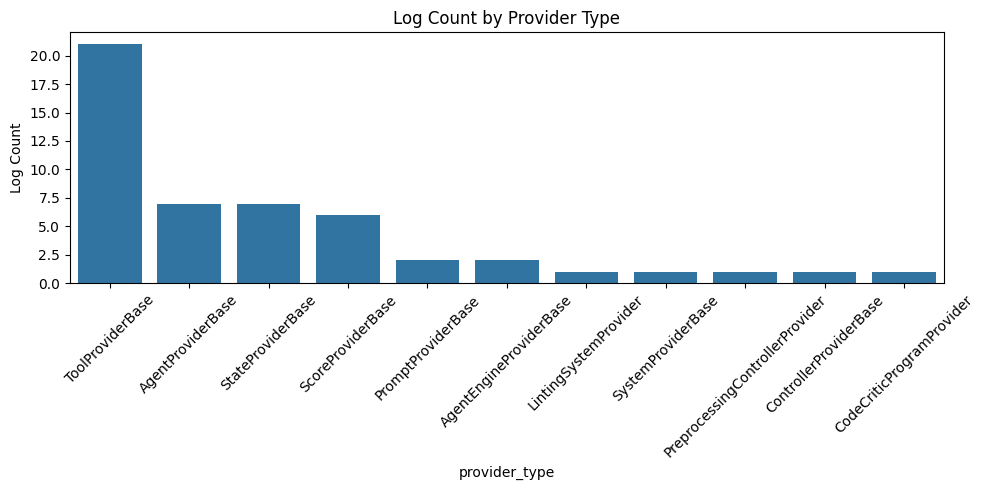

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("logs.csv")
provider_type_counts = df["provider_type"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=provider_type_counts.index, y=provider_type_counts.values)
plt.title("Log Count by Provider Type")
plt.ylabel("Log Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


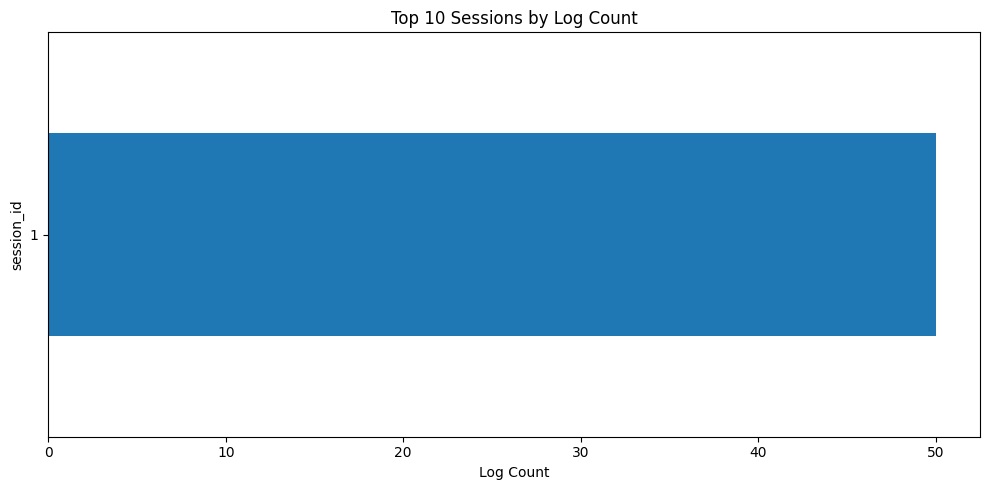

In [2]:
log_counts_by_session = df.groupby("session_id").size()
log_counts_by_session.nlargest(10).plot(kind="barh", figsize=(10, 5), title="Top 10 Sessions by Log Count")
plt.xlabel("Log Count")
plt.tight_layout()
plt.show()


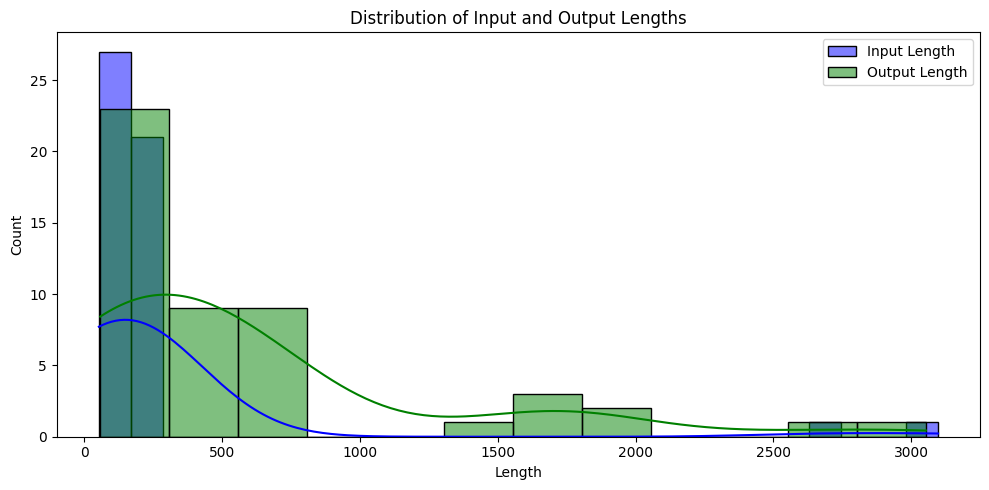

In [3]:
df["input_length"] = df["input"].dropna().apply(len)
df["output_length"] = df["output"].dropna().apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df["input_length"], kde=True, color="blue", label="Input Length")
sns.histplot(df["output_length"], kde=True, color="green", label="Output Length")
plt.legend()
plt.title("Distribution of Input and Output Lengths")
plt.xlabel("Length")
plt.tight_layout()
plt.show()


In [4]:
sampled = df.groupby("provider_type").apply(lambda g: g.sample(1)).reset_index(drop=True)
for _, row in sampled.iterrows():
    print(f"Provider Type: {row['provider_type']}")
    print("Input:")
    print(row['input'])
    print("Output:")
    print(row['output'])
    print("-" * 80)


Provider Type: AgentEngineProviderBase
Input:
{"prompt": "\n            You are the Generator Agent in the Linting System.\n\nYou specialize in incrementally improving Python code quality by addressing lint violations, enhancing readability, and promoting best practices.\n\nYour strategy is:\n\nFocus on minimal, targeted improvements that preserve original structure\n\nApply type hints and clarify variable names where appropriate\n\nUse reasoning to resolve tool-reported issues when they conflict\n\nYou will be evaluated by a Discriminator Agent and may be prompted to revise your output. If you are in a retry round, incorporate prior feedback before retrying.\n\nMaintain a helpful, confident tone in your comments. Your improvements should be easy for a human developer to understand and accept.\n\n\ud83d\udeab Your response must strictly follow this format:\n\n[CODE]\n# your revised Python code here\n[/CODE]\n\n[CONVERSATION_LOG_ENTRY]\n# bullet list of what changed, why, and tradeoffs 

C:\Users\ben\AppData\Local\Temp\ipykernel_58548\1489087.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby("provider_type").apply(lambda g: g.sample(1)).reset_index(drop=True)


C:\Users\ben\AppData\Local\Temp\ipykernel_58548\1993945397.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.resample('H').size().plot(title="Log Frequency Over Time", figsize=(12, 5))
c:\Repos\codecritic\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


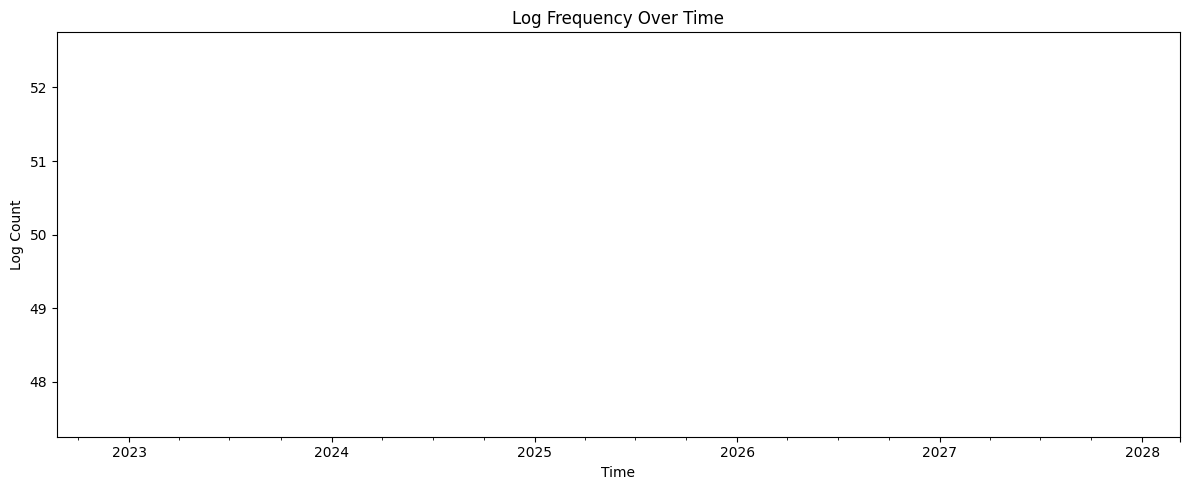

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.set_index('timestamp', inplace=True)
df.resample('H').size().plot(title="Log Frequency Over Time", figsize=(12, 5))
plt.ylabel("Log Count")
plt.xlabel("Time")
plt.tight_layout()
plt.show()
